In [18]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm)

<module 'exp_pybamm' from '/Users/noord/Library/CloudStorage/OneDrive-Chalmers/Master2/MSc_thesis/program/NNN/../exp_pybamm.py'>

In [9]:
I = np.load('../NO/data_NO/I.npz')['arr_0']   # X
V = np.load('../NO/data_NO/V.npz')['arr_0']   # y

# Reshape from (samples, 1, 1000) to (samples, 1000)
I = I.reshape(I.shape[0], -1)
V = V.reshape(V.shape[0], -1)

test_size = 0.1
I_test = I[0:int(test_size * len(I)),:]; V_test = V[0:int(test_size * len(I)),:]
I_train = I[int(test_size * len(I)):,:]; V_train = V[int(test_size * len(I)):,:]

In [10]:
def train_mlp_multioutput(X, y, verbose=True):
    """
    Train a multi-output MLPRegressor: X -> y (vectors).
    Applies feature scaling and target scaling for stability.
    Returns:
        pipeline, (X_test, y_test, y_pred), metrics_dict
    """

    X_train, X_test = X
    y_train, y_test = y

    base_mlp = MLPRegressor(
        hidden_layer_sizes=(256, 256),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        n_iter_no_change=15,
        batch_size=64,
        verbose=verbose,
    )

    pipeline = Pipeline([
        ("x_scaler", StandardScaler()),
        ("mlp", TransformedTargetRegressor(
            regressor=base_mlp,
            transformer=StandardScaler(with_mean=True, with_std=True)
        ))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = {
        "MSE": float(mean_squared_error(y_test, y_pred)),
        "MAE": float(mean_absolute_error(y_test, y_pred)),
        "R2": float(r2_score(y_test, y_pred)),
    }

    return pipeline, metrics

In [11]:
print("Training scikit-learn MLP (multi-output regression) ...")
model, metrics = train_mlp_multioutput(
    (I_train, I_test), (V_train, V_test), verbose=True
)
print("Test metrics:", metrics)

Training scikit-learn MLP (multi-output regression) ...
Iteration 1, loss = 0.55218635
Validation score: -0.081301
Iteration 2, loss = 0.49326104
Validation score: -0.048744
Iteration 3, loss = 0.47691378
Validation score: -0.031553
Iteration 4, loss = 0.46029381
Validation score: -0.011758
Iteration 5, loss = 0.43620759
Validation score: 0.017588
Iteration 6, loss = 0.40525721
Validation score: 0.057175
Iteration 7, loss = 0.36894329
Validation score: 0.105001
Iteration 8, loss = 0.33264684
Validation score: 0.151718
Iteration 9, loss = 0.29991248
Validation score: 0.197222
Iteration 10, loss = 0.27046095
Validation score: 0.236958
Iteration 11, loss = 0.24353505
Validation score: 0.266867
Iteration 12, loss = 0.21925846
Validation score: 0.292991
Iteration 13, loss = 0.19848248
Validation score: 0.313106
Iteration 14, loss = 0.18014994
Validation score: 0.336283
Iteration 15, loss = 0.16433761
Validation score: 0.358803
Iteration 16, loss = 0.15018312
Validation score: 0.377952
Itera

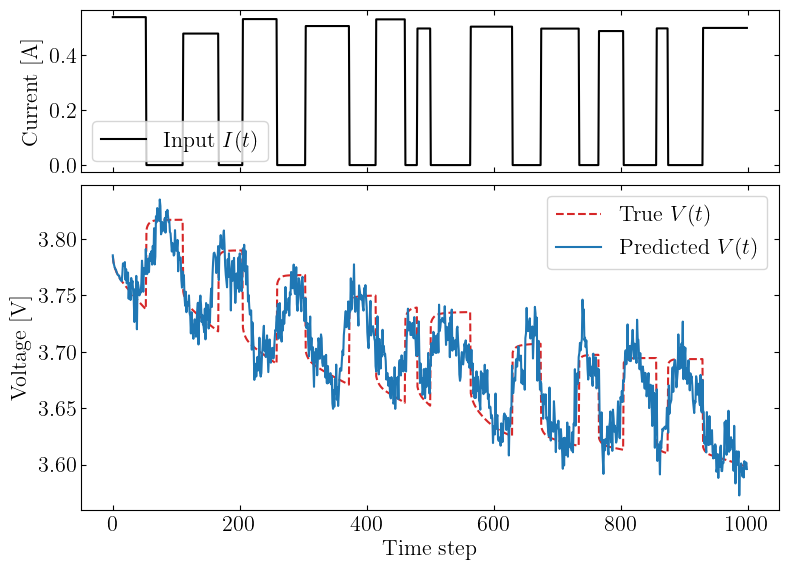

In [19]:
test = 0
i = I_test[test,:].reshape(1, -1) 
v = V_test[test,:].reshape(1, -1)

#print(i.shape, v.shape)
y_pred = model.predict(i)
f, ax = plt.subplots(2,1,figsize=(9,6.5), gridspec_kw={'height_ratios': [.5, 1]}, sharex=True)
f.subplots_adjust(hspace=0.05)

ax[0].plot(i.ravel(), label='Input $I(t)$', color='black')
ax[1].plot(v.ravel(), label='True $V(t)$', color='tab:red', linestyle='dashed')
ax[1].plot(y_pred.ravel(), label='Predicted $V(t)$', color='tab:blue')
ax[1].legend()
ax[0].legend()
ax[1].set_xlabel('Time step')
ax[0].set_ylabel('Current [A]')
ax[1].set_ylabel('Voltage [V]')
f.savefig('NNN_figs/NNN_pred.pdf')